# Krupa Gurav
# 24102C2005
# BE CMPN C


In [1]:
!pip install -q transformers datasets evaluate accelerate torch scikit-learn

import evaluate
import numpy as np
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


In [2]:
from datasets import VerificationMode

# 1. Load Dataset with split verification disabled
dataset = load_dataset(
    "mouryat9/CogBench", verification_mode=VerificationMode.NO_CHECKS
)

# Inspect columns to verify field names
print("Available splits:", dataset.keys())
print("Sample record:", dataset["train"][0])

README.md:   0%|          | 0.00/5.30k [00:00<?, ?B/s]

train.jsonl:   0%|          | 0.00/8.72M [00:00<?, ?B/s]

validation.jsonl:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/21827 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2636 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2636 [00:00<?, ? examples/s]

Available splits: dict_keys(['train', 'validation', 'test'])
Sample record: {'question_id': 'cogbench_19531', 'question_text': 'Virtual reality is a technology that has gotten a lot of attention recently. With companies like Microsoft promoting Mixed Reality and Meta (the company previously known as Facebook) promoting their Metaverse, VR has big companies behind it. Virtual reality, however, has been promoted in the past by game companies such as Nintendo but ended up fading away. Will virtual reality fade away again? What will make virtual reality a success? What impact do software engineers have on its success?', 'question_type': 'open_ended', 'subject': 'computer_science', 'source': 'openstax_mcq', 'bloom_level': 4, 'bloom_name': 'Analyze', 'label_source': 'ccs_phase1_silver', 'confidence': 0.7007}


In [3]:
# 2. Extract and Map Bloom's Labels Dynamically

# Define the ordered list of Bloom's cognitive levels (string names)
bloom_levels_names = [
    "Remember",
    "Understand",
    "Apply",
    "Analyze",
    "Evaluate",
    "Create",
]

# Mappings for AutoModelForSequenceClassification (model_id <-> bloom_name_string)
# These are the `id2label` and `label2id` that the model expects.
id2label = {i: name for i, name in enumerate(bloom_levels_names)} # int -> str
label2id = {name: i for i, name in enumerate(bloom_levels_names)} # str -> int

# Determine column names (from kernel state and dataset inspection)
text_col = "question_text" # For tokenizer input
label_col = "bloom_level" # This is the integer label (1-6) from the dataset to be mapped for training

# Mapping from dataset's original integer 'bloom_level' (1-6) to model's internal integer ID (0-5)
# This mapping will be used by the `preprocess_function` to assign integer labels for training.
# Since 'Remember' (index 0) corresponds to bloom_level 1, 'Understand' (index 1) to bloom_level 2, etc.,
# the model's internal ID is simply `dataset_bloom_level - 1`.
dataset_level_to_model_id_map = {
    lvl: lvl - 1 for lvl in sorted(list(set(dataset["train"][label_col])))
}

# The total number of unique labels for the model
num_unique_labels = len(bloom_levels_names)

print(f"Detected {num_unique_labels} classes: {id2label}")
print(f"Dataset bloom_level to model ID map: {dataset_level_to_model_id_map}")

Detected 6 classes: {0: 'Remember', 1: 'Understand', 2: 'Apply', 3: 'Analyze', 4: 'Evaluate', 5: 'Create'}
Dataset bloom_level to model ID map: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}


In [4]:
# 3. Tokenize with DistilBERT
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")


def preprocess_function(examples):
    # Corrected to use 'question_text' directly.
    tokens = tokenizer(
        examples[text_col], truncation=True, padding="max_length", max_length=128
    )
    # Use the specific mapping for the preprocess function
    tokens["label"] = [dataset_level_to_model_id_map[lvl] for lvl in examples[label_col]]
    return tokens


encoded_dataset = dataset.map(preprocess_function, batched=True)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/21827 [00:00<?, ? examples/s]

Map:   0%|          | 0/2636 [00:00<?, ? examples/s]

Map:   0%|          | 0/2636 [00:00<?, ? examples/s]

In [5]:
# 4. Initialize DistilBERT Model
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_unique_labels, # Use the correctly derived number of labels
    id2label=id2label,           # Use the id2label mapping for the model (int -> str)
    label2id=label2id,           # Use the label2id mapping for the model (str -> int)
)

# 5. Evaluation Metric Setup
f1_metric = evaluate.load("f1")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [6]:
# 6. Define compute_metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return f1_metric.compute(
        predictions=predictions, references=labels, average="weighted"
    )

In [7]:
# 7. Define Training Arguments
training_args = TrainingArguments(
    output_dir="./results",
    # evaluation_strategy="epoch", # Removed due to TypeError: unexpected keyword argument
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    # load_best_model_at_end=True, # Removed as it depends on evaluation_strategy
    # metric_for_best_model="f1",  # Removed as it depends on evaluation_strategy
    push_to_hub=False, # Set to True if you want to push your model to Hugging Face Hub
)

In [8]:
# Sample a smaller subset for quick experimentation
small_train_dataset = encoded_dataset["train"].shuffle(seed=42).select(range(2000))
small_eval_dataset = encoded_dataset["validation"].shuffle(seed=42).select(range(500))

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=375, training_loss=0.9734447428385417, metrics={'train_runtime': 115.1402, 'train_samples_per_second': 52.11, 'train_steps_per_second': 3.257, 'total_flos': 198715272192000.0, 'train_loss': 0.9734447428385417, 'epoch': 3.0})

=== Classification Report ===
              precision    recall  f1-score   support

    Remember     0.6094    0.6094    0.6094        64
  Understand     0.6400    0.3137    0.4211        51
       Apply     0.7241    0.8571    0.7850       147
     Analyze     0.7489    0.8410    0.7923       195
    Evaluate     0.7778    0.4375    0.5600        32
      Create     0.0000    0.0000    0.0000        11

    accuracy                         0.7180       500
   macro avg     0.5834    0.5098    0.5280       500
weighted avg     0.6980    0.7180    0.6966       500



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


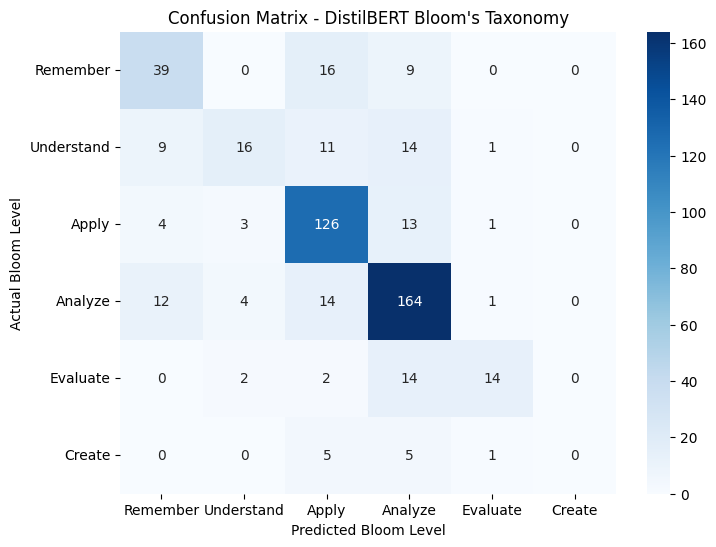

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions on the validation subset
predictions_output = trainer.predict(small_eval_dataset)
y_preds = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids

# Print full classification report (Precision, Recall, F1 for every Bloom level)
target_names = [id2label[i] for i in range(len(id2label))]
print("=== Classification Report ===")
print(
    classification_report(y_true, y_preds, target_names=target_names, digits=4)
)

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
)
plt.xlabel("Predicted Bloom Level")
plt.ylabel("Actual Bloom Level")
plt.title("Confusion Matrix - DistilBERT Bloom's Taxonomy")
plt.show()

In [10]:
import torch


def predict_bloom_level(question_text):
    # Set model to evaluation mode
    model.eval()

    # Tokenize input question
    inputs = tokenizer(
        question_text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=128,
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        predicted_class_id = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][predicted_class_id].item()

    predicted_label = id2label[predicted_class_id]
    return predicted_label, confidence


# Sample exam questions across different cognitive tiers
sample_questions = [
    "What is the definition of photosynthesis?",
    "Calculate the acceleration of a 5kg mass subjected to a 20N force.",
    "Compare and contrast supervised and unsupervised learning algorithms.",
    "Design a secure authentication system for a banking mobile app.",
    "Critique the author's argument regarding the economic impact of tariffs.",
]

print("\n=== Model Predictions on Sample Questions ===")
for q in sample_questions:
    level, conf = predict_bloom_level(q)
    print(f"Q: {q}")
    print(f"Predicted Level: {level} (Confidence: {conf*100:.2f}%)\n")


=== Model Predictions on Sample Questions ===
Q: What is the definition of photosynthesis?
Predicted Level: Remember (Confidence: 69.84%)

Q: Calculate the acceleration of a 5kg mass subjected to a 20N force.
Predicted Level: Apply (Confidence: 91.01%)

Q: Compare and contrast supervised and unsupervised learning algorithms.
Predicted Level: Analyze (Confidence: 86.24%)

Q: Design a secure authentication system for a banking mobile app.
Predicted Level: Apply (Confidence: 60.18%)

Q: Critique the author's argument regarding the economic impact of tariffs.
Predicted Level: Analyze (Confidence: 46.19%)



## Summary

### Model Performance Overview

The DistilBERT model was fine-tuned for Bloom's Taxonomy classification and evaluated on a validation subset. The overall accuracy was 71.80%.

#### Key Observations from Classification Report:

*   **Strong Performance in 'Apply' and 'Analyze':** The model showed good performance in identifying 'Apply' and 'Analyze' questions, with F1-scores of 0.7850 and 0.7923, respectively. This indicates it is relatively effective at classifying questions requiring application of knowledge or deeper analysis.
*   **Moderate Performance in 'Remember' and 'Understand':** 'Remember' questions had an F1-score of 0.6094, and 'Understand' questions had an F1-score of 0.4211. The model struggles more with 'Understand' questions, which is also reflected in its lower recall.
*   **Weak Performance in 'Evaluate' and 'Create':** The F1-scores for 'Evaluate' (0.5600) and 'Create' (0.0000) are notably lower. Specifically, for 'Create', the model had 0.00 precision, recall, and F1-score. This suggests the model failed to correctly identify any 'Create' level questions, which is a significant area for improvement.
*   **Weighted Average F1-score:** The weighted average F1-score was 0.6966, indicating reasonable overall performance, but with clear discrepancies across different Bloom's levels.

#### Key Observations from Confusion Matrix:

*   **High True Positives for 'Apply' (126) and 'Analyze' (164):** The model correctly classified a large number of 'Apply' and 'Analyze' questions, aligning with the higher F1-scores.
*   **Misclassifications from 'Remember' and 'Understand':** Questions from 'Remember' and 'Understand' are often misclassified into 'Apply' and 'Analyze', suggesting the model might sometimes over-interpret simpler questions as requiring more complex cognitive processes. For example, 16 'Remember' questions were predicted as 'Apply', and 11 'Understand' questions were predicted as 'Apply'.
*   **Failure to Predict 'Create' Level:** The confusion matrix shows that zero 'Create' questions were correctly predicted. Instead, 'Create' questions were misclassified into 'Apply' (5) and 'Analyze' (5), and 'Evaluate' (1).
*   **Confusion within Higher Levels:** There's some confusion between 'Analyze' and 'Evaluate' questions, with 'Evaluate' being misclassified as 'Analyze' (14 times).

### Conclusion:

While the model performs well on 'Apply' and 'Analyze' tasks, it struggles significantly with 'Understand', 'Evaluate', and especially 'Create' questions. Future work should focus on improving the model's ability to differentiate between these challenging cognitive levels, potentially through more diverse training data, class-weighted loss functions, or advanced model architectures suitable for subtle semantic distinctions.

## Kernel State
Here are some of the notable variables in the kernel:
Variable #1
name: `cm`, type: `ndarray`
value:
```
array([[ 39,   0,  16,   9,   0,   0],
       [  9,  16,  11,  14,   1,   0],
       [  4,   3, 126,  13,   1,   0],
       [ 12,   4,  14, 164,   1,   0],
       [  0,   2,   2,  14,  14,   0],
       [  0,   0,   5,   5,   1,   0]])
```
Variable #2
name: `y_preds`, type: `ndarray`
value:
```
array([3, 3, 0, 0, 2, 4, 3, 3, 3, 3, 3, 2, 0, 3, 2, 2, 3, 3, 3, 4, 3, 3,
       2, 2, 2, 2, 3, 3, 2, 0, 3, 3, 3, 3, 3, 0, 3, 2, 2, 3, 3, 2, 2, 3,
       1, 2, 3, 2, 0, 2, 1, 3, 3, 2, 3, 3, 0, 3, 2, 2, 2, 2, 3, 2, 3, 3,
       2, 0, 3, 0, 4, 2, 0, 2, 3, 3, 3, 3, 2, 3, 1, 3, 2, 2, 2, 1, 2, 0,
       2, 2, 3, 2, 2, 2, 2, 4, 2, 2, 2, 0, 3, 3, 3, 3, 2, 0, 2, 0, 2, 3,
       4, 4, 3, 3, 2, 2, 3, 3, 4, 3, 1, 2, 3, 4, 0, 0, 3, 2, 1, 3, 1, 3,
       2, 2, 3, 3, 1, 3, 3, 3,<TRUNCATED original_length=1661>
```
Variable #3
name: `y_true`, type: `ndarray`
value:
```
array([3, 3, 2, 3, 2, 4, 3, 3, 3, 3, 3, 3, 0, 3, 2, 2, 3, 3, 3, 4, 3, 3,
       2, 3, 1, 0, 1, 3, 2, 3, 3, 3, 3, 3, 3, 0, 3, 0, 2, 0, 3, 2, 2, 3,
       1, 2, 3, 3, 0, 3, 3, 1, 3, 0, 2, 3, 0, 3, 2, 2, 2, 2, 3, 2, 3, 3,
       2, 0, 2, 0, 5, 2, 0, 3, 1, 3, 3, 3, 2, 3, 1, 3, 0, 2, 2, 4, 5, 0,
       4, 2, 3, 2, 2, 2, 1, 2, 2, 0, 2, 0, 3, 4, 3, 3, 2, 1, 0, 3, 2, 3,
       1, 4, 3, 2, 2, 2, 3, 2, 4, 3, 1, 0, 3, 4, 3, 0, 3, 3, 4, 3, 1, 3,
       2, 2, 3, 4, 1, 3, 3, 3,<TRUNCATED original_length=1661>
```
Variable #4
name: `bloom_levels_names`, type: `list`
value: `['Remember', 'Understand', 'Apply', 'Analyze', 'Evaluate', 'Create']`
Variable #5
name: `conf`, type: `float`
value: `0.461859792470932`
Variable #6
name: `dataset_level_to_model_id_map`, type: `dict`
value: `{1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}`
Variable #7
name: `id2label`, type: `dict`
value: `{0: 'Remember', 1: 'Understand', 2: 'Apply', 3: 'Analyze', 4: 'Evaluate', 5: 'Create'}`
Variable #8
name: `label2id`, type: `dict`
value: `{'Remember': 0, 'Understand': 1, 'Apply': 2, 'Analyze': 3, 'Evaluate': 4, 'Create': 5}`
Variable #9
name: `label_col`, type: `str`
value: `'bloom_level'`
Variable #10
name: `level`, type: `str`
value: `'Analyze'`
Variable #11
name: `num_unique_labels`, type: `int`
value: `6`
Variable #12
name: `q`, type: `str`
value: `"Critique the author's argument regarding the economic impact of tariffs."`
Variable #13
name: `sample_questions`, type: `list`
value: `['What is the definition of photosynthesis?', 'Calculate the acceleration of a 5kg mass subjected to a 20N force.', 'Compare and contrast supervised and unsupervised learning algorithms.', 'Design a secure authentication system for a banking mobile app.', "Critique the author's argument regarding the economic impact of tariffs."]`
Variable #14
name: `target_names`, type: `list`
value: `['Remember', 'Understand', 'Apply', 'Analyze', 'Evaluate', 'Create']`
Variable #15
name: `text_col`, type: `str`
value: `'question_text'`